# 2 — Model

Train Random Forest classifier (backend selection) and regressor (runtime estimation) from the final canonical training tables emitted by `0_preprocess.ipynb`. Compare with baselines. Generate figures for the paper.

**Run after** `0_preprocess.ipynb`.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, mean_absolute_error, r2_score,
    root_mean_squared_error,
 )
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.005,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
C = ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F",
     "#EDC948", "#B07AA1", "#FF9DA7", "#9C755F", "#BAB0AC"]

COL1_W = 3.5
COL2_W = 7.16

BASE = Path("/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related")
IMG = Path("images")
IMG.mkdir(parents=True, exist_ok=True)

best_df = pd.read_csv("final_data/use_this_for_classification.csv")
est_df  = pd.read_csv("final_data/use_this_for_regression.csv")
core_metrics = [
    c for c in [
        "depth", "width", "n_ops", "two_qubit_gates",
        "clifford_count", "nonclifford_count",
        "critical_path_length", "connected_components", "num_parameters",
    ] if c in est_df.columns
 ]
SIM_BACKENDS = {"qtensor", "qiskitaer", "tnqvm", "nwqsim"}
LINESTYLE_BY_BACKEND = {
    "qtensor": "-",
    "qiskitaer": "-",
    "tnqvm": "-",
    "nwqsim": "-",
    "ionq": "--",
    "ibmq": "--",
}
print(f"Classification data: {best_df.shape}")
print(f"Regression data:     {est_df.shape}")
print(f"Backend classes:     {sorted(best_df['best_backend'].dropna().unique())}")
print(f"Canonical metrics available: {core_metrics}")

Classification data: (236, 141)
Regression data:     (3871, 149)
Backend classes:     ['ibmq', 'ionq', 'nwqsim', 'qiskitaer', 'tnqvm']
Canonical metrics available: ['depth', 'width', 'n_ops', 'two_qubit_gates', 'clifford_count', 'nonclifford_count', 'critical_path_length', 'connected_components', 'num_parameters']


## 1. Backend Selection (Classification)

Predict the best backend (lowest runtime) from circuit features + resource config.

In [2]:

# Drop rows without labels or core feature(s).
clf_df = best_df.dropna(subset=["best_backend", "depth"]).copy()
print(f"Usable classification rows: {len(clf_df)}")

# Target
y_cls = clf_df["best_backend"]

# Features: drop identifiers, target, and label-leaking columns.
# `sub_backend` is the winning backend's sub-backend -> leakage; drop it.
# `n_qubits` duplicates `size`.
drop_cols = [
    "best_backend", "best_runtime", "benchmark", "sub_backend", "n_qubits",
    "backend", "arg_backend", "arg_sub_backend", "provider", "target_backend",
    "winning_backend", "oracle_backend",
]
X_cls = clf_df.drop(columns=[c for c in drop_cols if c in clf_df.columns])

# Remove infrastructure/provenance metadata that should not drive model choices.
infra_tokens = ["slurm", "timestamp", "filename", "job_id", "session", "account", "frontend_cluster"]
infra_cols = [c for c in X_cls.columns if any(tok in c.lower() for tok in infra_tokens)]
if infra_cols:
    print(f"Dropping infra/provenance columns: {sorted(infra_cols)}")
    X_cls = X_cls.drop(columns=infra_cols)

# Guardrail: if any suspicious backend-id columns still exist, remove them.
suspicious = [
    c for c in X_cls.columns
    if ("backend" in c.lower() or "provider" in c.lower()) and c not in {"backend_family"}
]
if suspicious:
    print(f"Dropping potential leakage columns: {suspicious}")
    X_cls = X_cls.drop(columns=suspicious)

# Pearson r > 0.95 correlation pruning on numeric features (per paper).
num_cols_all = X_cls.select_dtypes(exclude=["object"]).columns.tolist()
if len(num_cols_all) > 1:
    corr = X_cls[num_cols_all].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    redundant = [c for c in upper.columns if (upper[c] > 0.95).any()]
    if redundant:
        print(f"Dropping {len(redundant)} highly-correlated features (r>0.95)")
        X_cls = X_cls.drop(columns=redundant)

cat_cols = X_cls.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_cls.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ("numeric", SimpleImputer(strategy="median"), num_cols),
])

clf_pipe = Pipeline([
    ("pre", preprocessor),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        max_depth=16,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )),
])

# Stratified 8:1:1 split: guarantees proportional class representation for rare classes.
# GroupShuffleSplit was allocating 3/9 ionq rows (33%) to test vs the expected 10%,
# causing 2 misclassifications to dominate the score. Stratified split fixes this.
print(f"Class distribution: {y_cls.value_counts().to_dict()}")

try:
    X_trva, X_te, y_trva, y_te = train_test_split(
        X_cls, y_cls, test_size=0.1, random_state=42, stratify=y_cls
    )
except ValueError as e:
    print(f"[warn] Stratified test split failed ({e}); using random split.")
    X_trva, X_te, y_trva, y_te = train_test_split(
        X_cls, y_cls, test_size=0.1, random_state=42
    )

try:
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_trva, y_trva, test_size=(1.0 / 9.0), random_state=42, stratify=y_trva
    )
except ValueError as e:
    print(f"[warn] Stratified val split failed ({e}); using random split.")
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_trva, y_trva, test_size=(1.0 / 9.0), random_state=42
    )

print(f"Split sizes -> train: {len(X_tr)}, val: {len(X_va)}, test: {len(X_te)}")
print(f"Test class distribution: {y_te.value_counts().to_dict()}")

# k=3 GroupKFold CV on train partition (group by workload to avoid near-duplicate leakage).
group_keys = [c for c in ["benchmark", "size", "n_nodes", "n_processes", "run_mode", "device"] if c in clf_df.columns]
if group_keys:
    groups_tr = clf_df.loc[X_tr.index, group_keys].astype(str).agg("|".join, axis=1)
else:
    groups_tr = pd.Series(index=X_tr.index, data=X_tr.index.astype(str))

if len(X_tr) >= 20 and groups_tr.nunique() >= 3:
    gkf = GroupKFold(n_splits=3)
    cv_scores = cross_val_score(
        clf_pipe, X_tr, y_tr,
        cv=gkf.split(X_tr, y_tr, groups=groups_tr),
        scoring="accuracy",
    )
    print(f"Group-CV (k=3) Accuracy on train: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
else:
    print("[warn] Not enough distinct groups for GroupKFold(k=3); skipping group CV.")

clf_pipe.fit(X_tr, y_tr)
y_val_hat = clf_pipe.predict(X_va)
val_acc = accuracy_score(y_va, y_val_hat)
val_f1 = f1_score(y_va, y_val_hat, average="macro", zero_division=0)
print(f"\n=== Validation Results ===")
print(f"Accuracy:  {val_acc:.3f}")
print(f"Macro-F1:  {val_f1:.3f}")

y_hat = clf_pipe.predict(X_te)
acc = accuracy_score(y_te, y_hat)
f1 = f1_score(y_te, y_hat, average="macro", zero_division=0)
print(f"\n=== Test Results ===")
print(f"Accuracy:  {acc:.3f}")
print(f"Macro-F1:  {f1:.3f}")
print(f"\nClassification Report (test):")
print(classification_report(y_te, y_hat, zero_division=0))


Usable classification rows: 191
Dropping potential leakage columns: ['be_backend_name', 'be_backend_type', 'be_backend_is_simulator']
Dropping 69 highly-correlated features (r>0.95)
Class distribution: {'nwqsim': 108, 'ibmq': 56, 'qiskitaer': 16, 'ionq': 9, 'tnqvm': 2}
Split sizes -> train: 152, val: 19, test: 20
Test class distribution: {'nwqsim': 11, 'ibmq': 6, 'qiskitaer': 2, 'ionq': 1}


/ccs/home/schundu3/.local/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'algo_gate_cu'
 'algo_gate_ccx' 'algo_gate_cp' 'algo_gate_u2' 'algo_gate_ry'
 'algo_gate_p' 'algo_gate_barrier' 'hw_gate_barrier' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/ccs/home/schundu3/.local/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'algo_gate_cu'
 'algo_gate_ccx' 'algo_gate_cp' 'algo_gate_u2' 'algo_gate_ry'
 'algo_gate_p' 'algo_gate_barrier' 'hw_gate_barrier' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/ccs/home/schundu3/.local/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_rx'
 'hw_gate_gpi2' 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/ccs/home/schundu3/.local/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_rx'
 'hw_gate_gpi2' 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/ccs/home/schundu3/.local/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/ccs/home/schundu3/.local/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/ccs/home/schundu3/.local/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Group-CV (k=3) Accuracy on train: 0.888 +/- 0.040



=== Validation Results ===
Accuracy:  0.947
Macro-F1:  0.905

=== Test Results ===
Accuracy:  0.950
Macro-F1:  0.906

Classification Report (test):
              precision    recall  f1-score   support

        ibmq       1.00      1.00      1.00         6
        ionq       1.00      1.00      1.00         1
      nwqsim       0.92      1.00      0.96        11
   qiskitaer       1.00      0.50      0.67         2

    accuracy                           0.95        20
   macro avg       0.98      0.88      0.91        20
weighted avg       0.95      0.95      0.94        20



/ccs/home/schundu3/.local/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/ccs/home/schundu3/.local/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [3]:
# ── Baselines: Heuristic-based selection (Fig. 1) + always-NWQSim ──
#
# The static "heuristic" baseline is the simulator-selection decision
# tree shown in Fig. 1 (label `fig:sim_heuristics`, citing Alexeev 2024).
# Its branches are, in order:
#     1. <50 qubits      → state-vector family
#     2. depth <100      → tensor-network family
#     3. mostly Clifford → near-Clifford family
#     4. otherwise       → "candidate for quantum advantage" (abstain)
# It picks a *family*, not a concrete implementation, so we score it as
# correct when the true winning backend belongs to the predicted family.

SIM_LABELS    = {"qiskitaer", "nwqsim", "qtensor", "tnqvm"}
FAMILY_SV     = {"qiskitaer", "nwqsim"}      # state-vector
FAMILY_TN     = {"qtensor", "tnqvm"}         # tensor-network
FAMILY_CLIFF  = {"qiskitaer", "nwqsim"}      # stabilizer paths inside SV sims
ABSTAIN       = set()                        # "quantum advantage" branch

def heuristic_family(row):
    """Static simulator selector from Fig. 1. Returns a backend family
    (set of allowed labels) or empty set if the heuristic abstains."""
    nq    = row.get("size", row.get("n_qubits", 0)) or 0
    depth = row.get("depth", 0) or 0
    cliff    = row.get("clifford_count", row.get("num_cliffords", 0)) or 0
    noncliff = row.get("nonclifford_count", row.get("num_non_cliffords", 0)) or 0
    if pd.isna(nq): nq = 0
    if pd.isna(depth): depth = 0
    if pd.isna(cliff): cliff = 0
    if pd.isna(noncliff): noncliff = 0
    total_gates = cliff + noncliff
    cliff_frac = (cliff / total_gates) if total_gates > 0 else 0.0

    # Order matches the flowchart top→bottom.
    if nq < 50:
        return FAMILY_SV
    if depth < 100:
        return FAMILY_TN
    if cliff_frac >= 0.95:
        return FAMILY_CLIFF
    return ABSTAIN  # quantum-advantage regime: heuristic gives up

# Restrict heuristic evaluation to simulator-only test rows (fair).
sim_mask = y_te.isin(SIM_LABELS)
y_te_sim = y_te[sim_mask]
X_te_sim = X_te.loc[sim_mask]

if len(y_te_sim) > 0:
    heur_fam = X_te_sim.apply(heuristic_family, axis=1)
    bl_heur_sim = float(np.mean([truth in fam
                                 for truth, fam in zip(y_te_sim, heur_fam)]))
else:
    bl_heur_sim = float("nan")

# Full-test fairness: the heuristic abstains on hardware backends (no
# rule for IBMQ/IonQ) and on the "quantum advantage" branch. Abstain =
# wrong, so this is the metric directly comparable to MQBac's accuracy.
bl_heur = (bl_heur_sim * len(y_te_sim) / len(y_te)) if len(y_te) else float("nan")

# Need `present` and `most_common` below.
present = set(y_cls.unique())
most_common = y_cls.value_counts().idxmax()

# Always-NWQSim baseline (paper requirement) — full test set.
bl_nwqsim = accuracy_score(y_te, ["nwqsim"] * len(y_te)) if "nwqsim" in present else float("nan")

# Always-most-common baseline (sanity check).
bl_always = accuracy_score(y_te, [most_common] * len(y_te))

# ── Wall-clock speedup of MQBac-recommended vs Always-NWQSim ──
# Build an exact (benchmark, size, backend, n_nodes, n_processes) → mean_ms
# lookup from est_df. Fall back to (benchmark, size, backend) mean if missing.
_rt_cols = [c for c in ["benchmark", "size", "backend", "n_nodes", "n_processes"] if c in est_df.columns]
_target = "runtime_ms" if "runtime_ms" in est_df.columns else "mean_ms"
_rt_full = est_df.dropna(subset=[_target]).groupby(_rt_cols, dropna=False)[_target].mean()
_rt_bsb  = est_df.dropna(subset=[_target]).groupby(["benchmark", "size", "backend"], dropna=False)[_target].mean()

def _lookup_runtime(row, backend):
    key_full = tuple([row.get("benchmark"), row.get("size"), backend] +
                     [row.get(c) for c in ["n_nodes", "n_processes"] if c in _rt_cols])
    if key_full in _rt_full.index:
        return float(_rt_full.loc[key_full])
    key_bsb = (row.get("benchmark"), row.get("size"), backend)
    if key_bsb in _rt_bsb.index:
        return float(_rt_bsb.loc[key_bsb])
    return float("nan")

clf_te_idx = X_te.index
test_rows = clf_df.loc[clf_te_idx]
mqbac_pred = clf_pipe.predict(X_te)

rt_mqbac = np.array([_lookup_runtime(r, p) for (_, r), p in zip(test_rows.iterrows(), mqbac_pred)])
rt_nwq   = np.array([_lookup_runtime(r, "nwqsim") for _, r in test_rows.iterrows()])
rt_oracle = test_rows["best_runtime"].to_numpy(dtype=float)

valid = np.isfinite(rt_mqbac) & np.isfinite(rt_nwq) & (rt_mqbac > 0)
speedup_vs_nwqsim = float(np.nanmean(rt_nwq[valid] / rt_mqbac[valid])) if valid.any() else float("nan")
oracle_speedup    = float(np.nanmean(rt_nwq[valid] / np.maximum(rt_oracle[valid], 1e-9))) if valid.any() else float("nan")

print(f"\n=== Baseline Comparison ===")
print(f"MQBac RF accuracy:                 {acc:.3f}")
print(f"Heuristic (sim-only, family-aware): {bl_heur_sim:.3f}  (n={len(y_te_sim)})")
print(f"Heuristic (full test, abstain=wrong): {bl_heur:.3f}  ({len(y_te_sim)}/{len(y_te)} covered)")
print(f"Always-NWQSim accuracy:            {bl_nwqsim:.3f}")
print(f"Always-{most_common} (most common):   {bl_always:.3f}")
print(f"Mean MQBac speedup vs NWQSim:      {speedup_vs_nwqsim:.2f}x   (oracle: {oracle_speedup:.2f}x)")
print(f"  (lookup coverage: {valid.sum()}/{len(valid)} test rows)")



=== Baseline Comparison ===
MQBac RF accuracy:                 0.950
Heuristic (sim-only, family-aware): 1.000  (n=13)
Heuristic (full test, abstain=wrong): 0.650  (13/20 covered)
Always-NWQSim accuracy:            0.550
Always-nwqsim (most common):   0.550
Mean MQBac speedup vs NWQSim:      3.86x   (oracle: 6.51x)
  (lookup coverage: 17/20 test rows)


/ccs/home/schundu3/.local/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


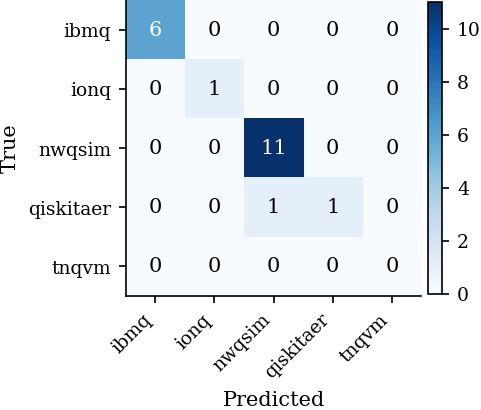

In [4]:
# Confusion matrix (single-column paper figure)
labels = sorted(y_cls.unique())
cm = confusion_matrix(y_te, y_hat, labels=labels)

fig, ax = plt.subplots(figsize=(COL1_W, COL1_W * 0.95))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
plt.tight_layout()
fig.savefig(IMG / "mqbac_confusion_matrix.pdf")
plt.show()


In [5]:
# === Classification Performance Table ===
from sklearn.metrics import classification_report
clf_report = classification_report(y_te, y_hat, output_dict=True, zero_division=0)
clf_df = pd.DataFrame(clf_report).transpose()
clf_df = clf_df[['precision', 'recall', 'f1-score', 'support']].round(3)
TABLES_DIR = Path("tables")
TABLES_DIR.mkdir(exist_ok=True)
with open(TABLES_DIR / "classification_performance.tex", "w") as f:
    f.write(clf_df.to_latex())
print("Saved: classification_performance.tex")
print(clf_df)

Saved: classification_performance.tex
              precision  recall  f1-score  support
ibmq              1.000   1.000     1.000     6.00
ionq              1.000   1.000     1.000     1.00
nwqsim            0.917   1.000     0.957    11.00
qiskitaer         1.000   0.500     0.667     2.00
accuracy          0.950   0.950     0.950     0.95
macro avg         0.979   0.875     0.906    20.00
weighted avg      0.954   0.950     0.943    20.00


In [6]:
# Per-class precision/recall plot removed (not used in paper; unstable signal across splits).
print("[skipped] mqbac_per_class_accuracy (removed as non-actionable)")

[skipped] mqbac_per_class_accuracy (removed as non-actionable)


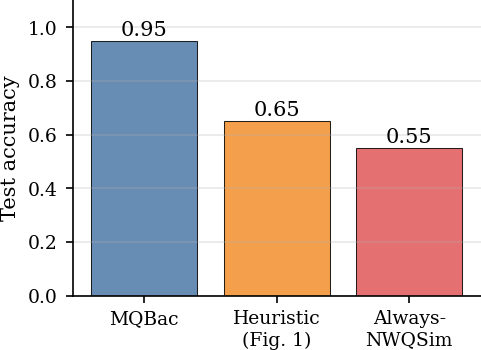

In [7]:
# Baseline comparison: MQBac vs Heuristic (Fig. 1, full-test, abstain=wrong)
# vs Always-NWQSim. `most_common` is dropped when it equals NWQSim to avoid
# duplicate bars.
methods = ["MQBac", "Heuristic\n(Fig.\u00a01)", "Always-\nNWQSim"]
accs    = [acc, bl_heur, bl_nwqsim]
bar_colors = [C[0], C[1], C[2]]
if most_common != "nwqsim":
    methods.append(f"Always-\n{most_common}")
    accs.append(bl_always)
    bar_colors.append(C[3])

fig, ax = plt.subplots(figsize=(COL1_W, COL1_W * 0.75))
bars = ax.bar(methods, accs, color=bar_colors, edgecolor="black",
              linewidth=0.5, alpha=0.85)
for bar, v in zip(bars, accs):
    if isinstance(v, float) and (v != v):
        continue
    ax.text(bar.get_x() + bar.get_width() / 2,
            v + 0.02 if v > 0.02 else 0.04,
            f"{v:.2f}", ha="center")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Test accuracy")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(IMG / "mqbac_baseline_comparison.pdf")
plt.show()


## 2. Runtime Estimation (Regression)

Predict `mean_ms` from circuit features + backend + resource config.

In [8]:

# Per the paper, the regressor predicts mean wall-clock time (`mean_ms`)
# per workload tuple. Aggregate per-sample timings to a per-tuple mean
# before training so target matches paper.
target_col = "runtime_ms" if "runtime_ms" in est_df.columns else "mean_ms"

reg_df = est_df.dropna(subset=[target_col]).copy()
# Note: do NOT filter on depth here; regression uses SimpleImputer for NaN features,
# so rows without depth can still contribute valid runtime observations.

# Filter zero/negative runtimes before aggregation: log1p(0)=0 distorts the
# target distribution and zero-ms values indicate errored/missing measurements.
reg_df = reg_df[reg_df[target_col] > 0].copy()
print(f"Rows after filtering runtime_ms > 0: {len(reg_df)}")
print(reg_df['backend'].value_counts().to_dict())

GROUP_KEYS = ["benchmark", "size", "backend", "sub_backend",
              "device", "run_mode", "n_nodes", "n_processes"]
group_keys = [c for c in GROUP_KEYS if c in reg_df.columns]

# Numeric features (mean) + categoricals (first) collapsed per group.
num_feat_cols = [c for c in reg_df.columns
                 if c not in group_keys + [target_col, "std_ms"]
                 and pd.api.types.is_numeric_dtype(reg_df[c])]
agg_dict = {target_col: "mean", **{c: "mean" for c in num_feat_cols}}
reg_mean_df = (
    reg_df.groupby(group_keys, dropna=False)
          .agg(agg_dict)
          .reset_index()
          .rename(columns={target_col: "mean_ms"})
)
print(f"Per-sample regression rows: {len(reg_df)}")
print(f"Aggregated to mean_ms per group: {len(reg_mean_df)}")

# Log-transform target: log1p(mean_ms) compresses the 10,000x dynamic range
# caused by ibmq queue times, enabling the model to learn relative ordering.
# R² is reported on log-scale (standard for log-normal targets); MAE/RMSE
# are back-transformed to ms for interpretability.
y_reg = np.log1p(reg_mean_df["mean_ms"].values)
print(f"Target range after log1p: [{y_reg.min():.2f}, {y_reg.max():.2f}]  "
      f"(original ms: [{reg_mean_df['mean_ms'].min():.0f}, {reg_mean_df['mean_ms'].max():.0f}])")

drop_cols = ["mean_ms", "std_ms", "n_qubits", "benchmark"]
X_reg = reg_mean_df.drop(columns=[c for c in drop_cols if c in reg_mean_df.columns])

# Remove infrastructure/provenance metadata that should not dominate feature ranks.
infra_tokens = ["slurm", "timestamp", "filename", "job_id", "session", "account", "frontend_cluster"]
infra_cols_reg = [c for c in X_reg.columns if any(tok in c.lower() for tok in infra_tokens)]
if infra_cols_reg:
    print(f"Dropping infra/provenance regression columns: {sorted(infra_cols_reg)}")
    X_reg = X_reg.drop(columns=infra_cols_reg)

# Pearson r > 0.95 correlation pruning on numeric features (per paper).
num_cols_all = X_reg.select_dtypes(exclude=["object"]).columns.tolist()
if len(num_cols_all) > 1:
    corr = X_reg[num_cols_all].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    redundant = [c for c in upper.columns if (upper[c] > 0.95).any()]
    if redundant:
        print(f"Dropping {len(redundant)} highly-correlated regression features (r>0.95)")
        X_reg = X_reg.drop(columns=redundant)

cat_cols_r = X_reg.select_dtypes(include=["object"]).columns.tolist()
num_cols_r = X_reg.select_dtypes(exclude=["object"]).columns.tolist()

pre_r = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols_r),
    ("numeric", SimpleImputer(strategy="median"), num_cols_r),
])

reg_pipe = Pipeline([
    ("pre", pre_r),
    ("rf", RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)),
])

# Random 8:1:1 split for regression (backend is an explicit feature, no label-leakage
# concern; group-wise split would test extrapolation to unseen workloads which is too strict).
Xr_trva, Xr_te, yr_trva, yr_te = train_test_split(
    X_reg, y_reg, test_size=0.1, random_state=42
)
Xr_tr, Xr_va, yr_tr, yr_va = train_test_split(
    Xr_trva, yr_trva, test_size=(1.0 / 9.0), random_state=42
)
print(f"Regression split (random 8:1:1) -> train: {len(Xr_tr)}, val: {len(Xr_va)}, test: {len(Xr_te)}")

# k=3 KFold CV on train partition.
from sklearn.model_selection import KFold
kf_r = KFold(n_splits=3, shuffle=True, random_state=42)
cv_r = cross_val_score(reg_pipe, Xr_tr, yr_tr, cv=kf_r, scoring="r2")
print(f"CV (k=3) R² on train (log-scale): {cv_r.mean():.3f} +/- {cv_r.std():.3f}")

reg_pipe.fit(Xr_tr, yr_tr)

yr_val_hat = reg_pipe.predict(Xr_va)
val_mae = mean_absolute_error(np.expm1(yr_va), np.expm1(yr_val_hat))
val_r2  = r2_score(yr_va, yr_val_hat)
print(f"\n=== Validation Results ===")
print(f"MAE:          {val_mae:.2f} ms  (back-transformed from log-scale)")
print(f"R² (log):     {val_r2:.3f}")

yr_hat = reg_pipe.predict(Xr_te)

# Back-transform to ms-scale for MAE/RMSE; R² reported on log-scale (per paper).
yr_te_ms  = np.expm1(yr_te)
yr_hat_ms = np.expm1(yr_hat)
mae  = mean_absolute_error(yr_te_ms, yr_hat_ms)
rmse = np.sqrt(((yr_te_ms - yr_hat_ms) ** 2).mean())
r2   = r2_score(yr_te, yr_hat)           # log-scale R² (reported in paper)
r2_orig = r2_score(yr_te_ms, yr_hat_ms)  # original ms-scale (reference)

print(f"\n=== Test Results ===")
print(f"Target: log1p(mean_ms) per (benchmark,size,backend,...) tuple")
print(f"MAE:              {mae:.2f} ms")
print(f"RMSE:             {rmse:.2f} ms")
print(f"R² (log-scale):   {r2:.3f}   ← reported in paper")
print(f"R² (orig ms):     {r2_orig:.3f}   (reference)")


Rows after filtering runtime_ms > 0: 3832
{'nwqsim': 1184, 'qiskitaer': 1027, 'ibmq': 789, 'ionq': 346, 'qtensor': 268, 'tnqvm': 218}
Per-sample regression rows: 3832
Aggregated to mean_ms per group: 621
Target range after log1p: [0.27, 15.45]  (original ms: [0, 5148219])


Dropping 82 highly-correlated regression features (r>0.95)
Regression split (random 8:1:1) -> train: 496, val: 62, test: 63


/ccs/home/schundu3/.local/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/ccs/home/schundu3/.local/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/ccs/home/schundu3/.local/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/ccs/home/schundu3/.local/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/ccs/home/schundu3/.local/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/ccs/home/schundu3/.local/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/ccs/home/schundu3/.local/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


CV (k=3) R² on train (log-scale): 0.816 +/- 0.038


/ccs/home/schundu3/.local/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/ccs/home/schundu3/.local/lib/python3.11/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(



=== Validation Results ===
MAE:          27930.72 ms  (back-transformed from log-scale)
R² (log):     0.885

=== Test Results ===
Target: log1p(mean_ms) per (benchmark,size,backend,...) tuple
MAE:              14730.34 ms
RMSE:             59312.58 ms
R² (log-scale):   0.948   ← reported in paper
R² (orig ms):     0.216   (reference)


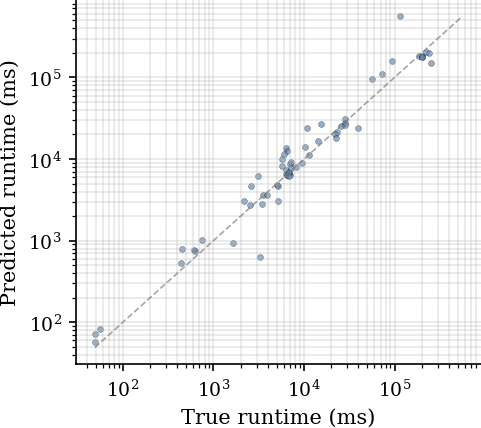

In [9]:

# Regression scatter (single-column paper figure, log-log handles huge dynamic range).
# Use back-transformed ms values so axes show actual wall-clock times.
fig, ax = plt.subplots(figsize=(COL1_W, COL1_W * 0.9))
ax.scatter(yr_te_ms, yr_hat_ms, s=8, alpha=0.6, color=C[0],
           edgecolors="black", linewidths=0.2)
_lo = max(min(yr_te_ms.min(), yr_hat_ms.min()), 1e-3)
_hi = max(yr_te_ms.max(), yr_hat_ms.max())
ax.plot([_lo, _hi], [_lo, _hi], "--", color="gray", linewidth=0.8, alpha=0.7)
if _hi / max(_lo, 1e-9) > 1e2:
    ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("True runtime (ms)")
ax.set_ylabel("Predicted runtime (ms)")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
fig.savefig(IMG / "mqbac_regression_scatter.pdf")
plt.show()


In [10]:
# === Regression Performance Table ===
reg_metrics = pd.DataFrame({
    "Metric": ["MAE (ms)", "RMSE (ms)", "R²", "Test samples"],
    "Value": [f"{mae:.2f}", f"{rmse:.2f}", f"{r2:.3f}", len(yr_te)]
})
with open(TABLES_DIR / "regression_performance.tex", "w") as f:
    f.write(reg_metrics.to_latex(index=False))
print("Saved: regression_performance.tex")
print(reg_metrics)

Saved: regression_performance.tex
         Metric     Value
0      MAE (ms)  14730.34
1     RMSE (ms)  59312.58
2            R²     0.948
3  Test samples        63


## 3. Feature Importance

Top-15 Gini importance from both the classifier and regressor.

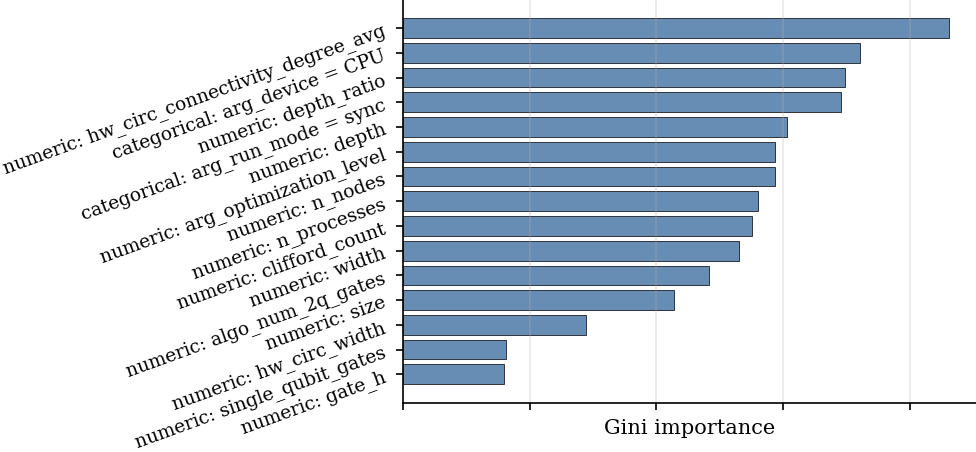

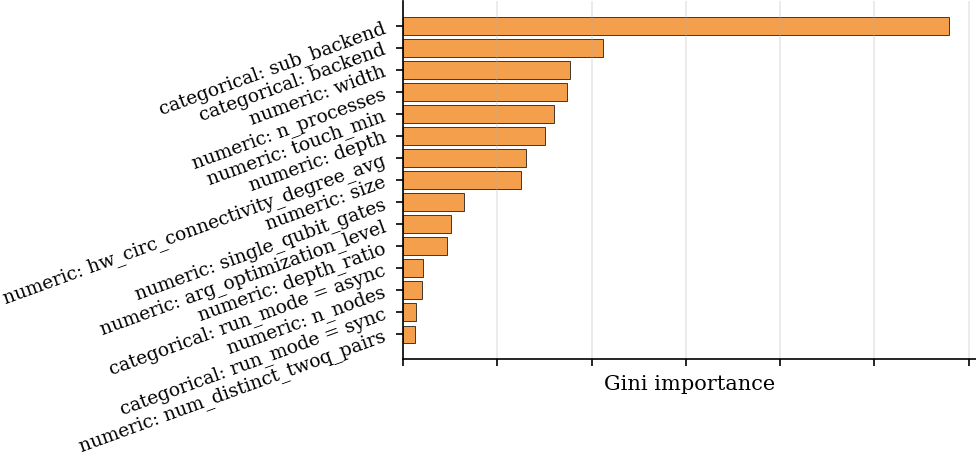

In [11]:
# Top-15 feature importance (separate paper figures: classifier and regressor).
def _split_categorical_raw(raw: str, feature_hints=None):
    hints = sorted(feature_hints or [], key=len, reverse=True)
    for feat in hints:
        if raw == feat:
            return feat, None
        prefix = feat + "_"
        if raw.startswith(prefix):
            return feat, raw[len(prefix):]
    # Fallback if no hint matches.
    parts = raw.split("_")
    if len(parts) >= 2:
        return "_".join(parts[:-1]), parts[-1]
    return raw, None

def pretty_feature_name(name: str, feature_hints=None) -> str:
    if name.startswith("categorical__"):
        raw = name[len("categorical__"):].strip()
        feat, category = _split_categorical_raw(raw, feature_hints)
        if category is None or category == "":
            return f"categorical: {feat}"
        return f"categorical: {feat} = {category}"
    if name.startswith("numeric__"):
        return f"numeric: {name[len('numeric__'):].strip()}"
    if name.startswith("cat__"):
        raw = name[len("cat__"):].strip()
        feat, category = _split_categorical_raw(raw, feature_hints)
        if category is None or category == "":
            return f"categorical: {feat}"
        return f"categorical: {feat} = {category}"
    if name.startswith("num__"):
        return f"numeric: {name[len('num__'):].strip()}"
    return name

def _is_nan_category(label: str) -> bool:
    return label.startswith("categorical:") and label.endswith(" = nan")

def _collapse_categorical_levels(labels, importances, collapse_features=None):
    agg = {}
    for label, importance in zip(labels, importances):
        if _is_nan_category(label):
            continue
        key = label
        if label.startswith("categorical: ") and " = " in label:
            feature = label[len("categorical: "):].split(" = ", 1)[0]
            if collapse_features is None or feature in collapse_features:
                key = f"categorical: {feature}"
        agg[key] = agg.get(key, 0.0) + float(importance)
    s = pd.Series(agg, dtype=float).sort_values(ascending=False)
    return s

# -- Classifier importance data --
rf_clf = clf_pipe.named_steps["rf"]
pre_clf = clf_pipe.named_steps["pre"]
try:
    feat_names_clf_raw = pre_clf.get_feature_names_out()
except AttributeError:
    feat_names_clf_raw = [f"f{i}" for i in range(len(rf_clf.feature_importances_))]
imp_clf_raw = rf_clf.feature_importances_

pretty_clf = np.array([pretty_feature_name(n, cat_cols) for n in feat_names_clf_raw], dtype=object)
keep_clf = np.array([not _is_nan_category(n) for n in pretty_clf], dtype=bool)
pretty_clf = pretty_clf[keep_clf]
imp_clf = imp_clf_raw[keep_clf]
order_clf = np.argsort(imp_clf)[::-1]
feat_names_clf = pretty_clf[order_clf]
imp_clf = imp_clf[order_clf]
idx_clf = np.arange(len(imp_clf))

# -- Regressor importance data --
rf_reg = reg_pipe.named_steps["rf"]
pre_reg = reg_pipe.named_steps["pre"]
try:
    feat_names_reg_raw = pre_reg.get_feature_names_out()
except AttributeError:
    feat_names_reg_raw = [f"f{i}" for i in range(len(rf_reg.feature_importances_))]
imp_reg_raw = rf_reg.feature_importances_

pretty_reg = np.array([pretty_feature_name(n, cat_cols_r) for n in feat_names_reg_raw], dtype=object)
collapsed_reg = _collapse_categorical_levels(
    pretty_reg,
    imp_reg_raw,
    collapse_features={"backend", "sub_backend"},
)
feat_names_reg = collapsed_reg.index.to_numpy()
imp_reg = collapsed_reg.values
idx_reg = np.arange(len(imp_reg))

# -- Plot 1: classifier --
fig, ax = plt.subplots(figsize=(COL2_W * 0.95, COL1_W * 0.95))
topn_clf = min(15, len(imp_clf))
ax.barh(range(topn_clf), imp_clf[:topn_clf][::-1], color=C[0], edgecolor="black",
        linewidth=0.4, alpha=0.85)
ax.set_yticks(range(topn_clf))
ax.set_yticklabels(feat_names_clf[:topn_clf][::-1])
ax.tick_params(axis="y", labelrotation=20)
ax.set_xlabel("Gini importance")
ax.tick_params(axis="x", labelbottom=False)
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(IMG / "mqbac_feature_importance_classifier.pdf")
plt.show()

# -- Plot 2: regressor --
fig, ax = plt.subplots(figsize=(COL2_W * 0.95, COL1_W * 0.95))
topn_reg = min(15, len(imp_reg))
ax.barh(range(topn_reg), imp_reg[:topn_reg][::-1], color=C[1], edgecolor="black",
        linewidth=0.4, alpha=0.85)
ax.set_yticks(range(topn_reg))
ax.set_yticklabels(feat_names_reg[:topn_reg][::-1])
ax.tick_params(axis="y", labelrotation=20)
ax.set_xlabel("Gini importance")
ax.tick_params(axis="x", labelbottom=False)
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(IMG / "mqbac_feature_importance_regressor.pdf")
plt.show()

In [12]:
# === Feature Importance Top-10 Table ===
top_10_clf = pd.DataFrame({
    "Rank": range(1, 11),
    "Classifier": [pretty_feature_name(feat_names_clf[i]) for i in idx_clf[:10]],
    "Importance": imp_clf[idx_clf[:10]].round(4)
})
top_10_reg = pd.DataFrame({
    "Rank": range(1, 11),
    "Regressor": [pretty_feature_name(feat_names_reg[i]) for i in idx_reg[:10]],
    "Importance": imp_reg[idx_reg[:10]].round(4)
})
# Side-by-side table
top_10 = pd.concat([top_10_clf, top_10_reg], axis=1)
with open(TABLES_DIR / "feature_importance_top10.tex", "w") as f:
    f.write(top_10.to_latex(index=False))
print("Saved: feature_importance_top10.tex")
print(top_10)

Saved: feature_importance_top10.tex
   Rank                                Classifier  Importance  Rank  \
0     1  numeric: hw_circ_connectivity_degree_avg      0.0861     1   
1     2             categorical: arg_device = CPU      0.0721     2   
2     3                      numeric: depth_ratio      0.0697     3   
3     4          categorical: arg_run_mode = sync      0.0690     4   
4     5                            numeric: depth      0.0606     5   
5     6           numeric: arg_optimization_level      0.0588     6   
6     7                          numeric: n_nodes      0.0586     7   
7     8                      numeric: n_processes      0.0561     8   
8     9                   numeric: clifford_count      0.0551     9   
9    10                            numeric: width      0.0530    10   

                                  Regressor  Importance  
0                  categorical: sub_backend      0.2894  
1                      categorical: backend      0.1058  
2       

## 4. Feature Correlation and PCA

Visualize which numeric QBacMet features move together, then project the standardized feature space into two principal components. The goal is to separate genuinely distinct signals from redundant metrics before interpreting feature importance.

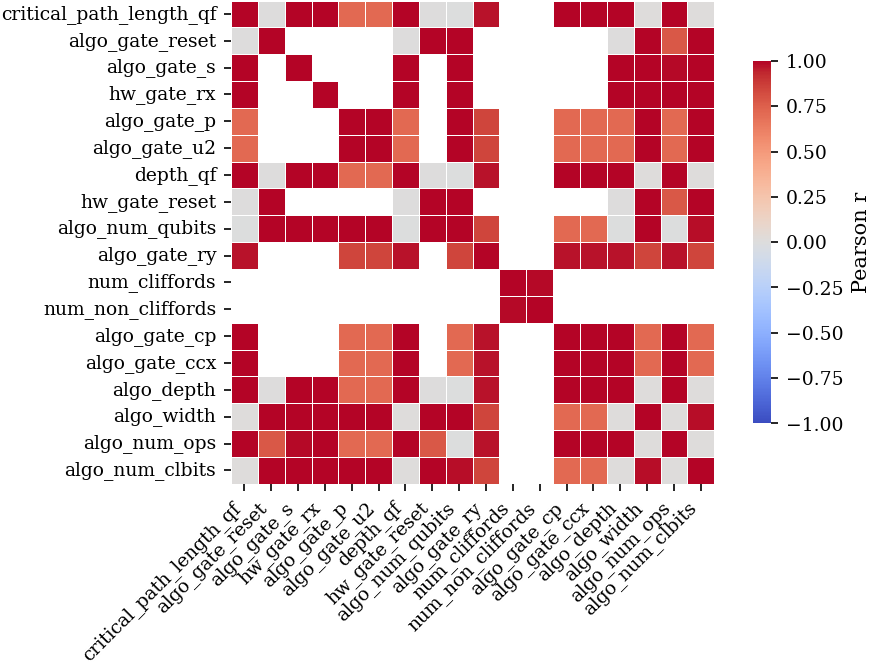

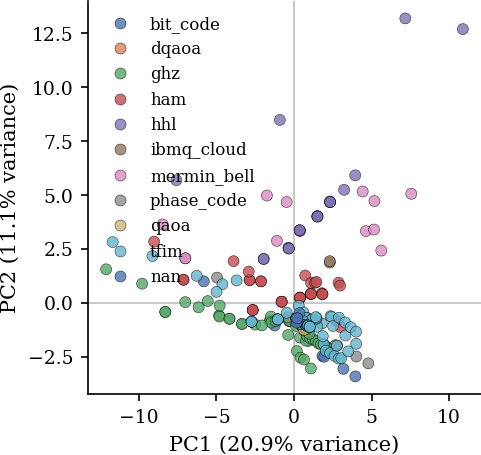

=== Feature correlation and PCA summary ===
Numeric features analyzed: 104
Highly-correlated pairs (|r| >= 0.80): 1517
Perfectly-correlated pairs (|r| == 1.0): 197
PCA rows after aggregation: 255
Features retained for PCA: 44 (dropped 59 at r > 0.95)
Top 8 absolute-correlation pairs:
  hw_circ_depth                vs hw_gate_rx                    r=1.000
  gate_p                       vs algo_gate_u2                  r=1.000
  hw_gate_rx                   vs critical_path_length_qf       r=1.000
  hw_circ_connected_components vs algo_gate_reset               r=1.000
  hw_circ_connected_components vs hw_gate_reset                 r=1.000
  critical_path_length         vs hw_gate_rx                    r=1.000
  algo_num_non_cliffords       vs hw_gate_rx                    r=1.000
  algo_gate_u2                 vs algo_gate_p                   r=1.000
Explained variance (PC1 + PC2): 32.1%
Top PC1 loading magnitudes:
  algo_gate_cx                  |loading|=0.289
  algo_num_2q_gates      

In [13]:
# Correlation structure + PCA on the numeric QBacMet feature space.

feature_drop_tokens = {
    "runtime_ms", "mean_ms", "std_ms",
    "best_runtime", "n_qubits",
}
meta_drop_cols = {
    "benchmark", "backend", "sub_backend", "device", "run_mode",
    "provider", "target_backend", "winning_backend", "oracle_backend",
    "arg_backend", "arg_sub_backend", "frontend_cluster",
}

corr_source = est_df.copy()
numeric_feature_cols = [
    c for c in corr_source.columns
    if c not in feature_drop_tokens
    and c not in meta_drop_cols
    and pd.api.types.is_numeric_dtype(corr_source[c])
]
corr_df = corr_source[numeric_feature_cols].apply(pd.to_numeric, errors="coerce")
corr_df = corr_df.dropna(axis=1, how="all")
corr_df = corr_df.loc[:, corr_df.nunique(dropna=True) > 1]

corr_matrix = corr_df.corr()
abs_upper = corr_matrix.abs().where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
pair_series = abs_upper.stack().sort_values(ascending=False)
high_corr_pairs = pair_series[pair_series >= 0.80]
perfect_pairs = pair_series[pair_series == 1.0]

top_corr_features = (
    abs_upper.fillna(0.0).max().sort_values(ascending=False).head(18).index.tolist()
    if len(abs_upper.columns) > 18 else abs_upper.columns.tolist()
 )
corr_plot = corr_matrix.loc[top_corr_features, top_corr_features]

fig, ax = plt.subplots(figsize=(COL2_W * 0.92, COL1_W * 1.35))
sns.heatmap(
    corr_plot,
    cmap="coolwarm",
    center=0.0,
    vmin=-1.0,
    vmax=1.0,
    square=True,
    linewidths=0.25,
    linecolor="white",
    cbar_kws={"shrink": 0.75, "label": "Pearson r"},
    ax=ax,
 )
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
fig.savefig(IMG / "model_feature_correlation_matrix_clusters.pdf")
plt.show()

pca_source = corr_source.copy()
pca_group_cols = [c for c in ["benchmark", "size", "backend"] if c in pca_source.columns]
pca_feature_cols = [c for c in corr_df.columns if c not in pca_group_cols]
if pca_group_cols:
    pca_source = (
        pca_source.groupby(pca_group_cols, dropna=False)[pca_feature_cols]
                  .mean()
                  .reset_index()
    )

pca_feature_df = pca_source[pca_feature_cols].copy()
pca_feature_df = pca_feature_df.fillna(pca_feature_df.median(numeric_only=True))

pca_corr = pca_feature_df.corr().abs()
pca_upper = pca_corr.where(np.triu(np.ones(pca_corr.shape), k=1).astype(bool))
pca_redundant = [c for c in pca_upper.columns if (pca_upper[c] > 0.95).any()]
if pca_redundant:
    pca_feature_df = pca_feature_df.drop(columns=pca_redundant)

nonnegative_cols = [c for c in pca_feature_df.columns if pca_feature_df[c].min() >= 0]
if nonnegative_cols:
    pca_feature_df.loc[:, nonnegative_cols] = np.log1p(pca_feature_df[nonnegative_cols])

scaled = StandardScaler().fit_transform(pca_feature_df)
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(scaled)
pca_plot_df = pd.DataFrame({
    "PC1": pcs[:, 0],
    "PC2": pcs[:, 1],
    "benchmark": pca_source["benchmark"].astype(str) if "benchmark" in pca_source.columns else "all",
})

loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_feature_df.columns,
    columns=["PC1", "PC2"],
 )
pc1_top = loadings["PC1"].abs().sort_values(ascending=False).head(5)
pc2_top = loadings["PC2"].abs().sort_values(ascending=False).head(5)

fig, ax = plt.subplots(figsize=(COL1_W, COL1_W * 0.95))
sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="benchmark",
    palette="deep",
    alpha=0.8,
    s=28,
    linewidth=0.25,
    edgecolor="black",
    ax=ax,
 )
ax.axhline(0.0, color="0.75", linewidth=0.8, zorder=0)
ax.axvline(0.0, color="0.75", linewidth=0.8, zorder=0)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
ax.legend(frameon=False, fontsize=8, loc="best")
plt.tight_layout()
fig.savefig(IMG / "feature_correlation_pca_projection.pdf")
plt.show()

print("=== Feature correlation and PCA summary ===")
print(f"Numeric features analyzed: {corr_df.shape[1]}")
print(f"Highly-correlated pairs (|r| >= 0.80): {len(high_corr_pairs)}")
print(f"Perfectly-correlated pairs (|r| == 1.0): {len(perfect_pairs)}")
print(f"PCA rows after aggregation: {len(pca_feature_df)}")
print(f"Features retained for PCA: {pca_feature_df.shape[1]} (dropped {len(pca_redundant)} at r > 0.95)")
if len(high_corr_pairs) > 0:
    print("Top 8 absolute-correlation pairs:")
    for (lhs, rhs), value in high_corr_pairs.head(8).items():
        print(f"  {lhs:28s} vs {rhs:28s}  r={value:.3f}")
print(f"Explained variance (PC1 + PC2): {(pca.explained_variance_ratio_.sum() * 100):.1f}%")
print("Top PC1 loading magnitudes:")
for feat, value in pc1_top.items():
    print(f"  {feat:28s}  |loading|={abs(value):.3f}")
print("Top PC2 loading magnitudes:")
for feat, value in pc2_top.items():
    print(f"  {feat:28s}  |loading|={abs(value):.3f}")

## 5. Hidden Performance Crossovers

The abstract claims meta-backend benchmarking *uncovers crossovers
opaque to traditional benchmarking*. This figure shows mean wall-clock
runtime vs qubit count, one curve per backend, faceted by benchmark.
Crossovers are identified from line intersections and ranking changes
across backend curves as qubits grow.

Solid lines denote simulator backends, while dashed lines denote
hardware/cloud backends to make mixed workflow crossovers easier to read.

Plotting 9 series:
  qtensor
  tnqvm
  qiskitaer/statevector
  qiskitaer/mps
  qiskitaer/automatic
  nwqsim
  ionq/simulator
  ibmq_boston
  ibmq_miami


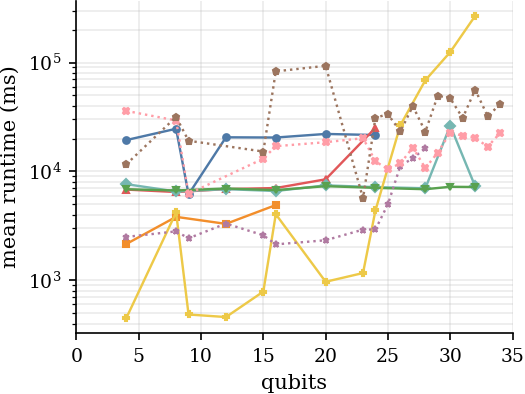

Saved: images/mqbac_backend_crossovers_ghz.pdf


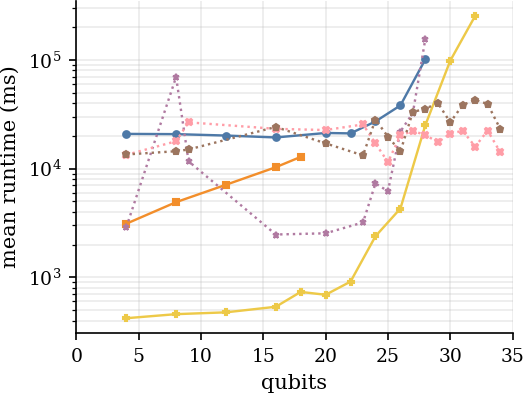

Saved: images/mqbac_backend_crossovers_tfim.pdf


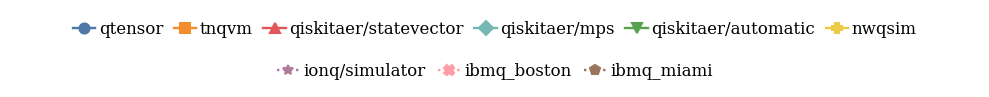

Saved: images/mqbac_crossover_legend.pdf


In [14]:
# Backend crossover figures (paper headline: "hidden crossovers").
# Simulators (solid "-"): qtensor, tnqvm, qiskitaer/statevector, qiskitaer/mps,
#                         qiskitaer/automatic, nwqsim
# Hardware/cloud (dotted ":"): ionq/simulator, ibmq_boston, ibmq_miami
# Legend: two centered rows, no legend embedded in plots.
_t = "runtime_ms" if "runtime_ms" in est_df.columns else "mean_ms"

SINGLE_LINE_BACKENDS = {"qtensor", "tnqvm", "nwqsim"}
SPLIT_BACKENDS = {"qiskitaer", "ibmq", "ionq"}

# Allowlists
KEEP_QK_SUBS = {"statevector", "matrix_product_state", "automatic"}
KEEP_IBMQ_SUBS = {"ibm_boston", "ibm_miami"}
KEEP_IONQ_SUBS = {"simulator"}

_df_all = est_df.dropna(subset=[_t, "benchmark", "size", "backend"]).copy()
_df_all["_be"] = _df_all["backend"].str.lower()

_xover_single = (
    _df_all[_df_all["_be"].isin(SINGLE_LINE_BACKENDS)]
    .groupby(["benchmark", "size", "_be"], dropna=False)[_t]
    .mean().reset_index()
    .rename(columns={"_be": "backend"})
    .assign(sub_backend=None)
)
_xover_split = (
    _df_all[_df_all["_be"].isin(SPLIT_BACKENDS)]
    .groupby(["benchmark", "size", "_be", "sub_backend"], dropna=False)[_t]
    .mean().reset_index()
    .rename(columns={"_be": "backend"})
)

_xover = pd.concat([_xover_single, _xover_split], ignore_index=True)
_xover = _xover[np.isfinite(_xover[_t]) & (_xover[_t] > 0)].copy()

def _allowed(row):
    be, sb = row["backend"], row["sub_backend"]
    if be in SINGLE_LINE_BACKENDS:
        return True
    if be == "qiskitaer":
        return str(sb) in KEEP_QK_SUBS
    if be == "ibmq":
        return str(sb) in KEEP_IBMQ_SUBS
    if be == "ionq":
        return str(sb) in KEEP_IONQ_SUBS
    return False

_xover = _xover[_xover.apply(_allowed, axis=1)].copy()

_bench_map = {b.lower(): b for b in _xover["benchmark"].dropna().unique()}
_benches = [_bench_map[k] for k in ["ghz", "tfim"] if k in _bench_map]

# Fixed 9-series style catalog (backend, sub_backend, color_idx, marker, linestyle, label).
_SERIES = [
    ("qtensor", None, 0, "o", "-", "qtensor"),
    ("tnqvm", None, 1, "s", "-", "tnqvm"),
    ("qiskitaer", "statevector", 2, "^", "-", "qiskitaer/statevector"),
    ("qiskitaer", "matrix_product_state", 3, "D", "-", "qiskitaer/mps"),
    ("qiskitaer", "automatic", 4, "v", "-", "qiskitaer/automatic"),
    ("nwqsim", None, 5, "P", "-", "nwqsim"),
    ("ionq", "simulator", 6, "*", ":", "ionq/simulator"),
    ("ibmq", "ibm_boston", 7, "X", ":", "ibmq_boston"),
    ("ibmq", "ibm_miami", 8, "p", ":", "ibmq_miami"),
]
_style_map = {(be, sb): (C[ci], ls, mk, lbl) for be, sb, ci, mk, ls, lbl in _SERIES}

def _get_style(be, sb):
    key = (be, None if (sb is None or (isinstance(sb, float) and np.isnan(sb))) else sb)
    return _style_map.get(key, (C[4], "-", "o", str(be)))

# Exact order requested by user.
_ROW1 = [
    ("qtensor", None),
    ("tnqvm", None),
    ("qiskitaer", "statevector"),
    ("qiskitaer", "matrix_product_state"),
    ("qiskitaer", "automatic"),
    ("nwqsim", None),
]
_ROW2 = [
    ("ionq", "simulator"),
    ("ibmq", "ibm_boston"),
    ("ibmq", "ibm_miami"),
]
_ordered_all = _ROW1 + _ROW2

_present = {
    (row["backend"], row["sub_backend"] if pd.notna(row.get("sub_backend")) else None)
    for _, row in _xover.iterrows()
}
_ordered_plot = [(be, sb) for (be, sb) in _ordered_all if (be, sb) in _present]
print(f"Plotting {len(_ordered_plot)} series:")
for _be, _sb in _ordered_plot:
    _, _, _, _lbl = _get_style(_be, _sb)
    print(f"  {_lbl}")

# Per-benchmark plots (no embedded legend).
for bench in _benches:
    sub_b = _xover[_xover["benchmark"] == bench].copy()
    if sub_b["backend"].nunique() < 2:
        print(f"[skip] {bench}: only one backend.")
        continue

    fig, ax = plt.subplots(figsize=(COL1_W, COL1_W * 0.75))
    for (be, sb) in _ordered_plot:
        if be in SINGLE_LINE_BACKENDS:
            mask = sub_b["backend"] == be
        elif sb is None:
            mask = (sub_b["backend"] == be) & sub_b["sub_backend"].isna()
        else:
            mask = (sub_b["backend"] == be) & (sub_b["sub_backend"].astype(str) == str(sb))
        g = sub_b[mask].sort_values("size")
        if len(g) == 0:
            continue
        color, ls, marker, label = _get_style(be, sb)
        ax.plot(
            g["size"], g[_t], marker=marker, linestyle=ls, color=color,
            markersize=3.2, linewidth=1.15, label=label
        )

    max_size = int(sub_b["size"].max())
    tick_end = 5 * int(np.ceil(max_size / 5.0))
    xticks = np.arange(0, tick_end + 1, 5)
    if len(xticks) == 0:
        xticks = np.array(sorted(sub_b["size"].unique()))
    ax.set_xticks(xticks)
    ax.set_xlim(0, max(max_size, xticks.max()))
    ax.set_yscale("log")
    ax.set_xlabel("qubits")
    ax.set_ylabel("mean runtime (ms)")
    ax.grid(True, which="both", alpha=0.25)
    plt.tight_layout(pad=0.03)
    out = IMG / f"mqbac_backend_crossovers_{bench.lower()}.pdf"
    fig.savefig(out, bbox_inches="tight", pad_inches=0.001)
    plt.show()
    print(f"Saved: {out}")

# Shared legend: two centered rows, tightly packed for LaTeX compositing.
fig_leg, ax_leg = plt.subplots(figsize=(COL2_W * 0.92, 0.64))
ax_leg.set_axis_off()
fig_leg.subplots_adjust(left=0.0, right=1.0, top=1.0, bottom=0.0)

handles_row1 = []
for be, sb in _ROW1:
    color, ls, marker, label = _get_style(be, sb)
    h, = ax_leg.plot([], [], marker=marker, linestyle=ls, color=color,
                     markersize=4.8, linewidth=1.15, label=label)
    handles_row1.append(h)

handles_row2 = []
for be, sb in _ROW2:
    color, ls, marker, label = _get_style(be, sb)
    h, = ax_leg.plot([], [], marker=marker, linestyle=ls, color=color,
                     markersize=4.8, linewidth=1.15, label=label)
    handles_row2.append(h)

leg1 = ax_leg.legend(
    handles=handles_row1, loc="upper center", ncol=6,
    bbox_to_anchor=(0.5, 0.86), frameon=False, fontsize=8,
    handletextpad=0.22, columnspacing=0.62, handlelength=1.35, borderaxespad=0.0,
 )
ax_leg.add_artist(leg1)
ax_leg.legend(
    handles=handles_row2, loc="lower center", ncol=3,
    bbox_to_anchor=(0.5, 0.10), frameon=False, fontsize=8,
    handletextpad=0.22, columnspacing=0.75, handlelength=1.35, borderaxespad=0.0,
 )

leg_out = IMG / "mqbac_crossover_legend.pdf"
fig_leg.savefig(leg_out, bbox_inches="tight", pad_inches=0.001)
plt.show()
print(f"Saved: {leg_out}")

## 6. Summary for Paper

Numbers needed for Section 6 of `meta_backend_paper`.


In [15]:
print("=" * 60)
print("  NUMBERS FOR THE PAPER  (Section 6)")
print("=" * 60)

def _missing(required):
    return [k for k in required if k not in globals()]

cls_required = [
    "acc", "f1", "bl_heur_sim", "bl_heur", "bl_nwqsim", "bl_always",
    "most_common", "speedup_vs_nwqsim",
]
reg_required = ["mae", "rmse", "r2"]
clf_imp_required = ["idx_clf", "feat_names_clf", "imp_clf", "pretty_feature_name"]
reg_imp_required = ["idx_reg", "feat_names_reg", "imp_reg", "pretty_feature_name"]

print("\n[Classification]")
missing = _missing(cls_required)
if missing:
    print("  Unavailable in current kernel.")
    print(f"  Missing variables: {', '.join(missing)}")
    print("  Run the classification/evaluation cells above, then rerun this summary cell.")
else:
    print(f"  Accuracy:                            {acc:.3f}")
    print(f"  Macro-F1:                            {f1:.3f}")
    print(f"  Heuristic (Fig. 1, sim-only):        {bl_heur_sim:.3f}")
    print(f"  Heuristic (Fig. 1, full test):       {bl_heur:.3f}")
    print(f"  Always-NWQSim:                       {bl_nwqsim:.3f}")
    print(f"  Always-{most_common} (most-common):     {bl_always:.3f}")
    print(f"  Mean speedup vs Always-NWQSim:       {speedup_vs_nwqsim:.2f}x")

print("\n[Regression]  (target = mean_ms per workload tuple)")
missing = _missing(reg_required)
if missing:
    print("  Unavailable in current kernel.")
    print(f"  Missing variables: {', '.join(missing)}")
else:
    print(f"  MAE:   {mae:.2f} ms")
    print(f"  RMSE:  {rmse:.2f} ms")
    print(f"  R²:    {r2:.3f}")

print("\n[Feature Importance — Classifier top 5]")
missing = _missing(clf_imp_required)
if missing:
    print("  Unavailable in current kernel.")
    print(f"  Missing variables: {', '.join(missing)}")
else:
    for rank, i in enumerate(idx_clf[:5], 1):
        print(f"  {rank}. {pretty_feature_name(feat_names_clf[i]):30s}  {imp_clf[i]:.4f}")

print("\n[Feature Importance — Regressor top 5]")
missing = _missing(reg_imp_required)
if missing:
    print("  Unavailable in current kernel.")
    print(f"  Missing variables: {', '.join(missing)}")
else:
    for rank, i in enumerate(idx_reg[:5], 1):
        print(f"  {rank}. {pretty_feature_name(feat_names_reg[i]):30s}  {imp_reg[i]:.4f}")

  NUMBERS FOR THE PAPER  (Section 6)

[Classification]
  Accuracy:                            0.950
  Macro-F1:                            0.906
  Heuristic (Fig. 1, sim-only):        1.000
  Heuristic (Fig. 1, full test):       0.650
  Always-NWQSim:                       0.550
  Always-nwqsim (most-common):     0.550
  Mean speedup vs Always-NWQSim:       3.86x

[Regression]  (target = mean_ms per workload tuple)
  MAE:   14730.34 ms
  RMSE:  59312.58 ms
  R²:    0.948

[Feature Importance — Classifier top 5]
  1. numeric: hw_circ_connectivity_degree_avg  0.0861
  2. categorical: arg_device = CPU   0.0721
  3. numeric: depth_ratio            0.0697
  4. categorical: arg_run_mode = sync  0.0690
  5. numeric: depth                  0.0606

[Feature Importance — Regressor top 5]
  1. categorical: sub_backend        0.2894
  2. categorical: backend            0.1058
  3. numeric: width                  0.0883
  4. numeric: n_processes            0.0869
  5. numeric: touch_min            

In [16]:
# TEMP CHECK: metrics and figure consistency audit
import numpy as np
import pandas as pd

def _safe(name):
    return globals().get(name, None)

print('=== METRICS (from current kernel vars) ===')
for k in [
    'acc', 'f1', 'bl_heur_sim', 'bl_heur', 'bl_nwqsim',
    'bl_always', 'most_common', 'speedup_vs_nwqsim',
    'mae', 'rmse', 'r2'
]:
    v = _safe(k)
    print(f'{k}={v if v is not None else "NA (not in kernel)"}')

if _safe('y_te') is not None:
    print(f'test_cls_rows={len(y_te)}')
else:
    print('test_cls_rows=NA (y_te not in kernel)')

if _safe('yr_te') is not None:
    print(f'test_reg_rows={len(yr_te)}')
else:
    print('test_reg_rows=NA (yr_te not in kernel)')

print('\n=== CROSSOVER STAR ELIGIBILITY ===')
if _safe('est_df') is None:
    print('est_df not in kernel; run setup cell first.')
else:
    _t = 'runtime_ms' if 'runtime_ms' in est_df.columns else 'mean_ms'
    _xover = (
        est_df.dropna(subset=[_t, 'benchmark', 'size', 'backend'])
              .groupby(['benchmark', 'size', 'backend'], dropna=False)[_t]
              .mean()
              .reset_index()
    )
    _xover = _xover[np.isfinite(_xover[_t]) & (_xover[_t] > 0)].copy()
    print(f'rows_for_crossover={len(_xover)}')
    print(f'benchmarks_for_crossover={sorted(_xover["benchmark"].dropna().unique())}')

=== METRICS (from current kernel vars) ===
acc=0.95
f1=0.9057971014492753
bl_heur_sim=1.0
bl_heur=0.65
bl_nwqsim=0.55
bl_always=0.55
most_common=nwqsim
speedup_vs_nwqsim=3.8612685995794407
mae=14730.336414434056
rmse=59312.5776132275
r2=0.9477174462914019
test_cls_rows=20
test_reg_rows=63

=== CROSSOVER STAR ELIGIBILITY ===
rows_for_crossover=250
benchmarks_for_crossover=['bit_code', 'dqaoa', 'ghz', 'ham', 'hhl', 'ibmq_cloud', 'mermin_bell', 'phase_code', 'qaoa', 'tfim']


In [17]:
# TEMP CHECK 2: derived paper numbers
import numpy as np
import pandas as pd

print('=== DERIVED NUMBERS ===')
n_total = len(y_te)
n_correct = int(np.sum(np.array(mqbac_pred) == np.array(y_te)))
n_err = int(n_total - n_correct)
print(f'classification_errors={n_err} of {n_total} ({(n_err/n_total)*100:.2f}%)')

# Simulator-only accuracy on the held-out test rows (if backend column available).
sim_labels = {'nwqsim', 'qtensor', 'qiskitaer', 'tnqvm'}
sim_acc = None
if 'backend' in X_te.columns:
    _mask = X_te['backend'].astype(str).str.lower().isin(sim_labels).to_numpy()
    if _mask.any():
        sim_acc = float(np.mean(np.array(mqbac_pred)[_mask] == np.array(y_te)[_mask]))
        print(f'mqbac_sim_only_test_accuracy={sim_acc:.6f} (n={int(_mask.sum())})')
    else:
        print('mqbac_sim_only_test_accuracy=NA (no simulator rows in test)')
else:
    print('mqbac_sim_only_test_accuracy=NA (backend column absent in X_te)')

# Depth inflation summary from raw qbacmet
qflat_chk = pd.read_csv('final_data/qbacmet_flat.csv')
hw_chk = qflat_chk.dropna(subset=['algo_depth', 'hw_circ_depth']).copy()
hw_chk = hw_chk[hw_chk['algo_depth'] > 0]
hw_chk['depth_ratio'] = hw_chk['hw_circ_depth'] / hw_chk['algo_depth']
print(f'depth_inflation_median={hw_chk["depth_ratio"].median():.6f}')
print(f'depth_inflation_max={hw_chk["depth_ratio"].max():.6f}')

# Correlation-matrix claims from analyze logic
rt_chk = pd.read_csv('final_data/use_this_for_regression.csv')
circuit_features_chk = [
    c for c in rt_chk.columns
    if c.startswith('gate_') or c in [
        'n_qubits', 'depth', 'width', 'n_clbits', 'n_ops', 'n_gates',
        'n_parameters', 'n_connected_components', 'n_measure_ops',
        'single_qubit_gates', 'two_qubit_gates', 'three_qubit_gates',
        'four_qubit_gates', 'num_separable_circuits', 'num_tensor_factors',
        'num_serial_layers', 'qc_width_total', 'num_registers', 'num_cregs',
        'num_ancillas', 'idle_wires', 'global_phase', 'dag_size_ops',
        'dag_edge_count', 'longest_path_len', 'num_control_flow_ops',
        'num_barriers', 'num_distinct_twoq_pairs', 'touch_min', 'touch_max',
        'touch_avg', 'clifford_count', 'nonclifford_count', 'measure_fraction',
        'total_gate_params', 'avg_gate_params', 'std_gate_params',
        'min_gate_params', 'max_gate_params', 'num_controlled_gates',
        'num_unitary_factors', 'dag_duration', 'qc_duration']
 ]
circuit_features_chk = [c for c in circuit_features_chk if c in rt_chk.columns]
X_circ_chk = rt_chk[circuit_features_chk].apply(pd.to_numeric, errors='coerce')
X_circ_chk = X_circ_chk.dropna(axis=1, how='all')
X_circ_chk = X_circ_chk.loc[:, X_circ_chk.nunique(dropna=True) > 1]
corr_chk = X_circ_chk.corr()
upper_chk = corr_chk.where(np.triu(np.ones(corr_chk.shape), k=1).astype(bool))
pairs_08_099 = int(((upper_chk.abs() >= 0.80) & (upper_chk.abs() < 0.99)).sum().sum())
pairs_eq_10 = int((upper_chk.abs() == 1.0).sum().sum())
print(f'corr_feature_count={corr_chk.shape[0]}')
print(f'corr_pairs_abs_0p80_to_0p99={pairs_08_099}')
print(f'corr_pairs_abs_eq_1p00={pairs_eq_10}')

=== DERIVED NUMBERS ===
classification_errors=1 of 20 (5.00%)
mqbac_sim_only_test_accuracy=NA (backend column absent in X_te)
depth_inflation_median=2.900000
depth_inflation_max=34.523669


corr_feature_count=43
corr_pairs_abs_0p80_to_0p99=70
corr_pairs_abs_eq_1p00=21


In [18]:
print(f"acc={acc:.4f}  f1={f1:.4f}  bl_heur={bl_heur:.4f}  bl_nwqsim={bl_nwqsim:.4f}  speedup={speedup_vs_nwqsim:.4f}  mae={mae:.2f}  rmse={float(rmse):.2f}  r2={r2:.4f}")

acc=0.9500  f1=0.9058  bl_heur=0.6500  bl_nwqsim=0.5500  speedup=3.8613  mae=14730.34  rmse=59312.58  r2=0.9477
